
#### PROYECTO: Análisis de la variabilidad del cambio del bosque en el Chaco Seco
Área de estudio: Provincia de Córdoba
#
Descripción:
Este script analiza la dinámica de:
 - Expansión del riego por pivote
 - Pérdida de cobertura arbórea
 - Evolución de coberturas del suelo
 a diferentes escalas (provincial y departamental)



In [2]:
# 0. CONFIGURACIÓN INICIAL
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
print("librerias ok")

librerias ok


In [3]:
# Directorio de trabajo
os.chdir("D:/Josefina/Proyectos/Bosques/codigo")

In [5]:
# Estética del proyecto
sns.set_theme(style="whitegrid")
# Paleta base
col_verde = "#238b45"
col_azul = "#3182bd"

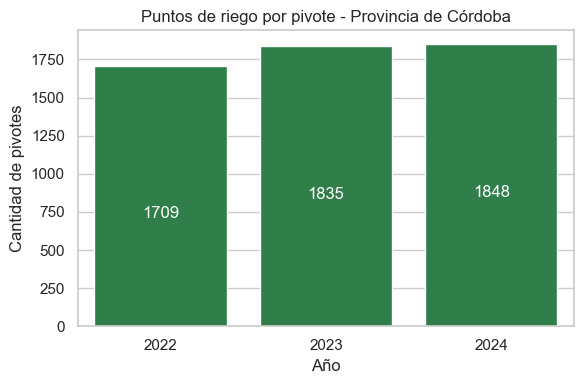

In [ ]:
# 1. EXPANSIÓN DEL RIEGO POR PIVOTE (2022–2024)

data_riego = pd.DataFrame({
    "year": [2022, 2023, 2024],
    "puntos_total": [1709, 1835, 1848],
    "superficie_total": [123370, 130180, 132514],
    "puntos_nuevos": [239, 249, 251],
    "superficie_nueva": [20579, 21727, 22241]
})


# 1.1 Puntos totales de riego
#Plot

plt.figure(figsize=(6,4))
sns.barplot(data=data_riego, x="year", y="puntos_total", color=col_verde)

for i, v in enumerate(data_riego["puntos_total"]):
    plt.text(i, v - 1000, str(v), ha='center', color='white')

plt.title("Puntos de riego por pivote - Provincia de Córdoba")
plt.xlabel("Año")
plt.ylabel("Cantidad de pivotes")
plt.tight_layout()
plt.show()



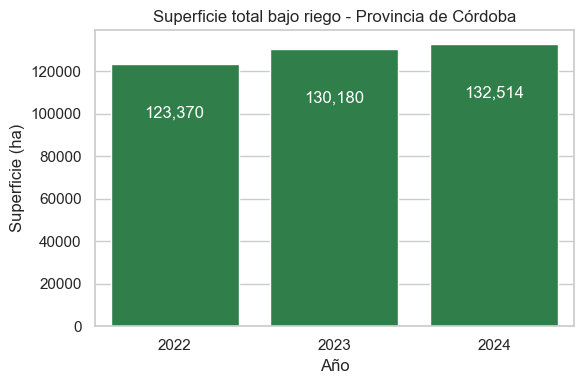

In [14]:
# 1.2 Superficie total bajo riego

plt.figure(figsize=(6,4))
sns.barplot(data=data_riego, x="year", y="superficie_total", color=col_verde)

for i, v in enumerate(data_riego["superficie_total"]):
    plt.text(i, v - 25000, f"{v:,}", ha='center', color='white')

plt.title("Superficie total bajo riego - Provincia de Córdoba")
plt.xlabel("Año")
plt.ylabel("Superficie (ha)")
plt.tight_layout()
plt.show()


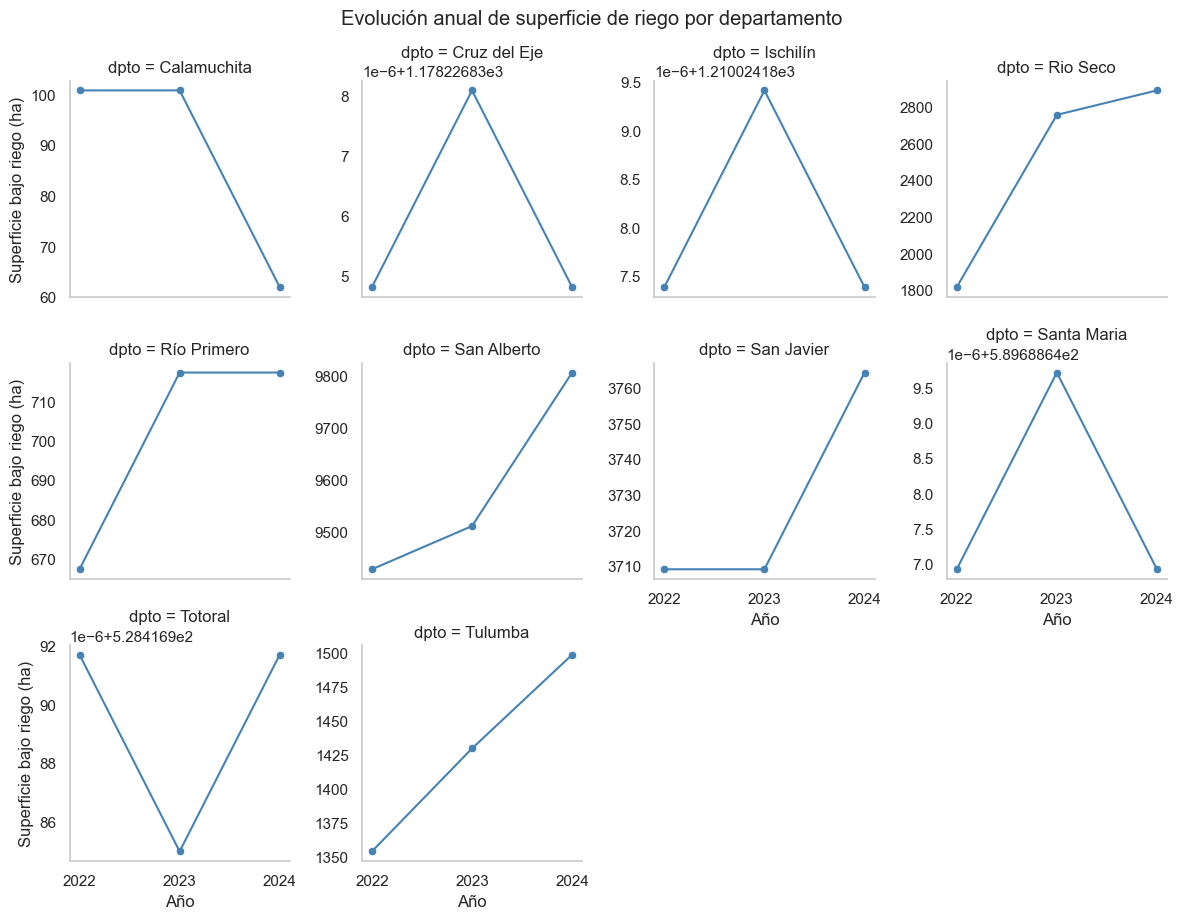

In [ ]:
# 2. RIEGO POR PIVOTE EN CHACO SECO (ESCALA DEPARTAMENTAL)

df = pd.read_csv(
    "D:/Josefina/Proyectos/Bosques/data/Riego_pivot_resumen.csv",
    encoding="latin1"
)

df = df[df["tipo"] == "CS"]

# -----------------------------------------------------------------------------
# 2.1 Resumen por departamento y año
# -----------------------------------------------------------------------------

df_sum = (
    df.groupby(["dpto", "year"])
      .agg(superficie_ha=("SupercieHa", "sum"),
           cantidad_pivotes=("SupercieHa", "count"))
      .reset_index()
)

df_sum["year"] = df_sum["year"].astype(int)


# 2.2 Evolución anual por departamento

g = sns.FacetGrid(df_sum, col="dpto", col_wrap=4, sharey=False, height=3)

g.map_dataframe(sns.lineplot, x="year", y="superficie_ha", color="steelblue")
g.map_dataframe(sns.scatterplot, x="year", y="superficie_ha", color="steelblue")

# Quitar grid en todos los subplots
for ax in g.axes.flatten():
    ax.grid(False)

g.set_axis_labels("Año", "Superficie bajo riego (ha)")
g.fig.suptitle("Evolución anual de superficie de riego por departamento",
               y=1.02)

plt.show()

#Revisar algunos de los dptos con datos 

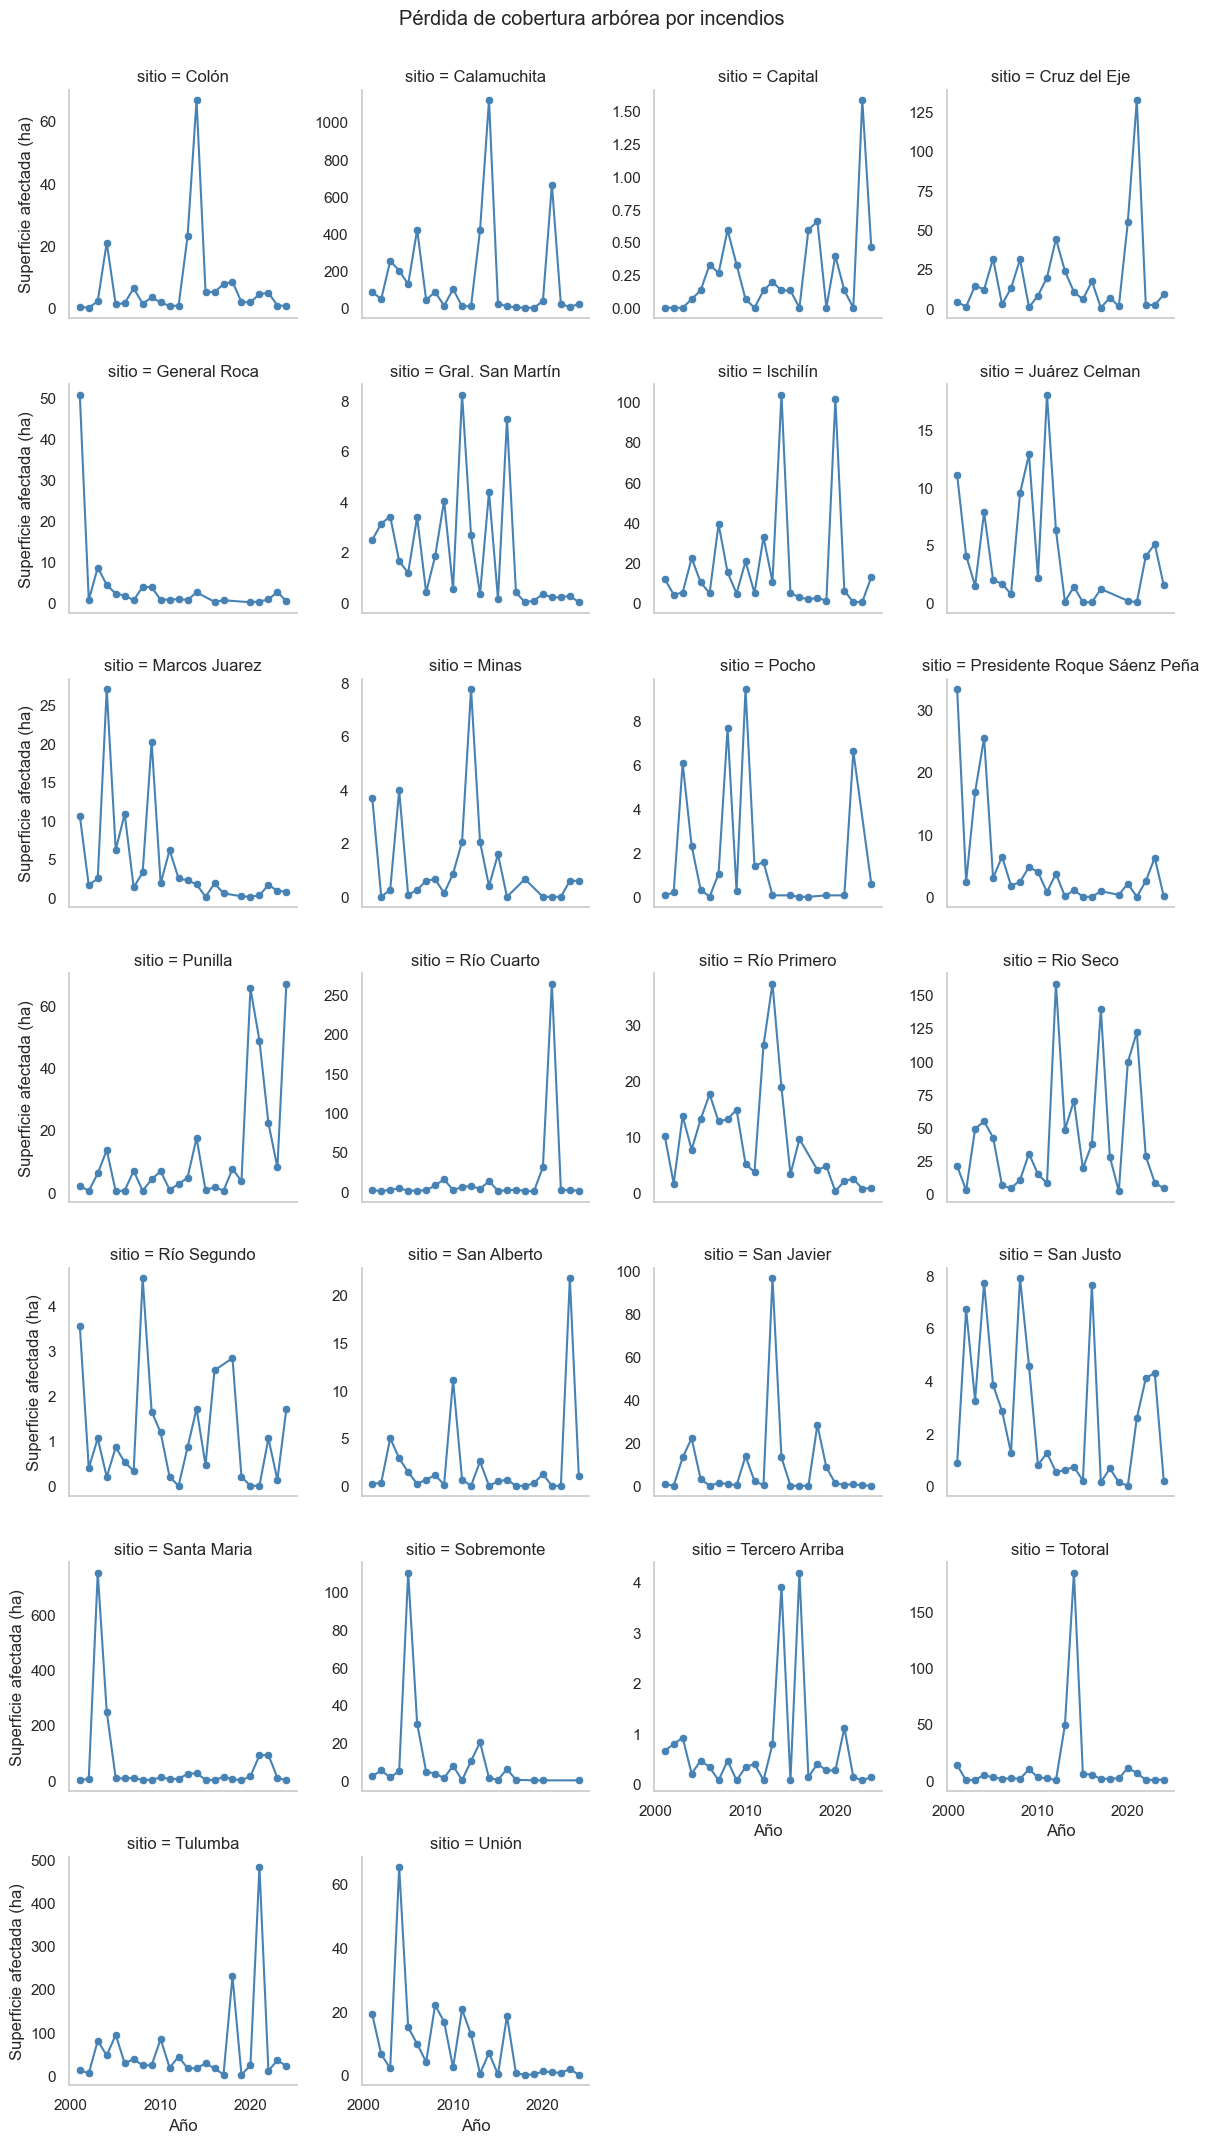

In [21]:
# 3. PÉRDIDA DE COBERTURA ARBÓREA POR INCENDIOS

df = pd.read_csv(
    "D:/Josefina/Proyectos/Bosques/data/dataset.csv",
    encoding="latin1"
)

df_incendios = df[df["tipo"] == "perdida_cobertura_arborea_incendios"]

g = sns.FacetGrid(df_incendios, col="sitio", col_wrap=4, sharey=False, height=3)

g.map_dataframe(sns.lineplot, x="year_2", y="valor", color="steelblue")
g.map_dataframe(sns.scatterplot, x="year_2", y="valor", color="steelblue")
# Quitar grid en todos los subplots
for ax in g.axes.flatten():
    ax.grid(False)
g.set_axis_labels("Año", "Superficie afectada (ha)")
g.fig.suptitle("Pérdida de cobertura arbórea por incendios", y=1.02)

plt.show()




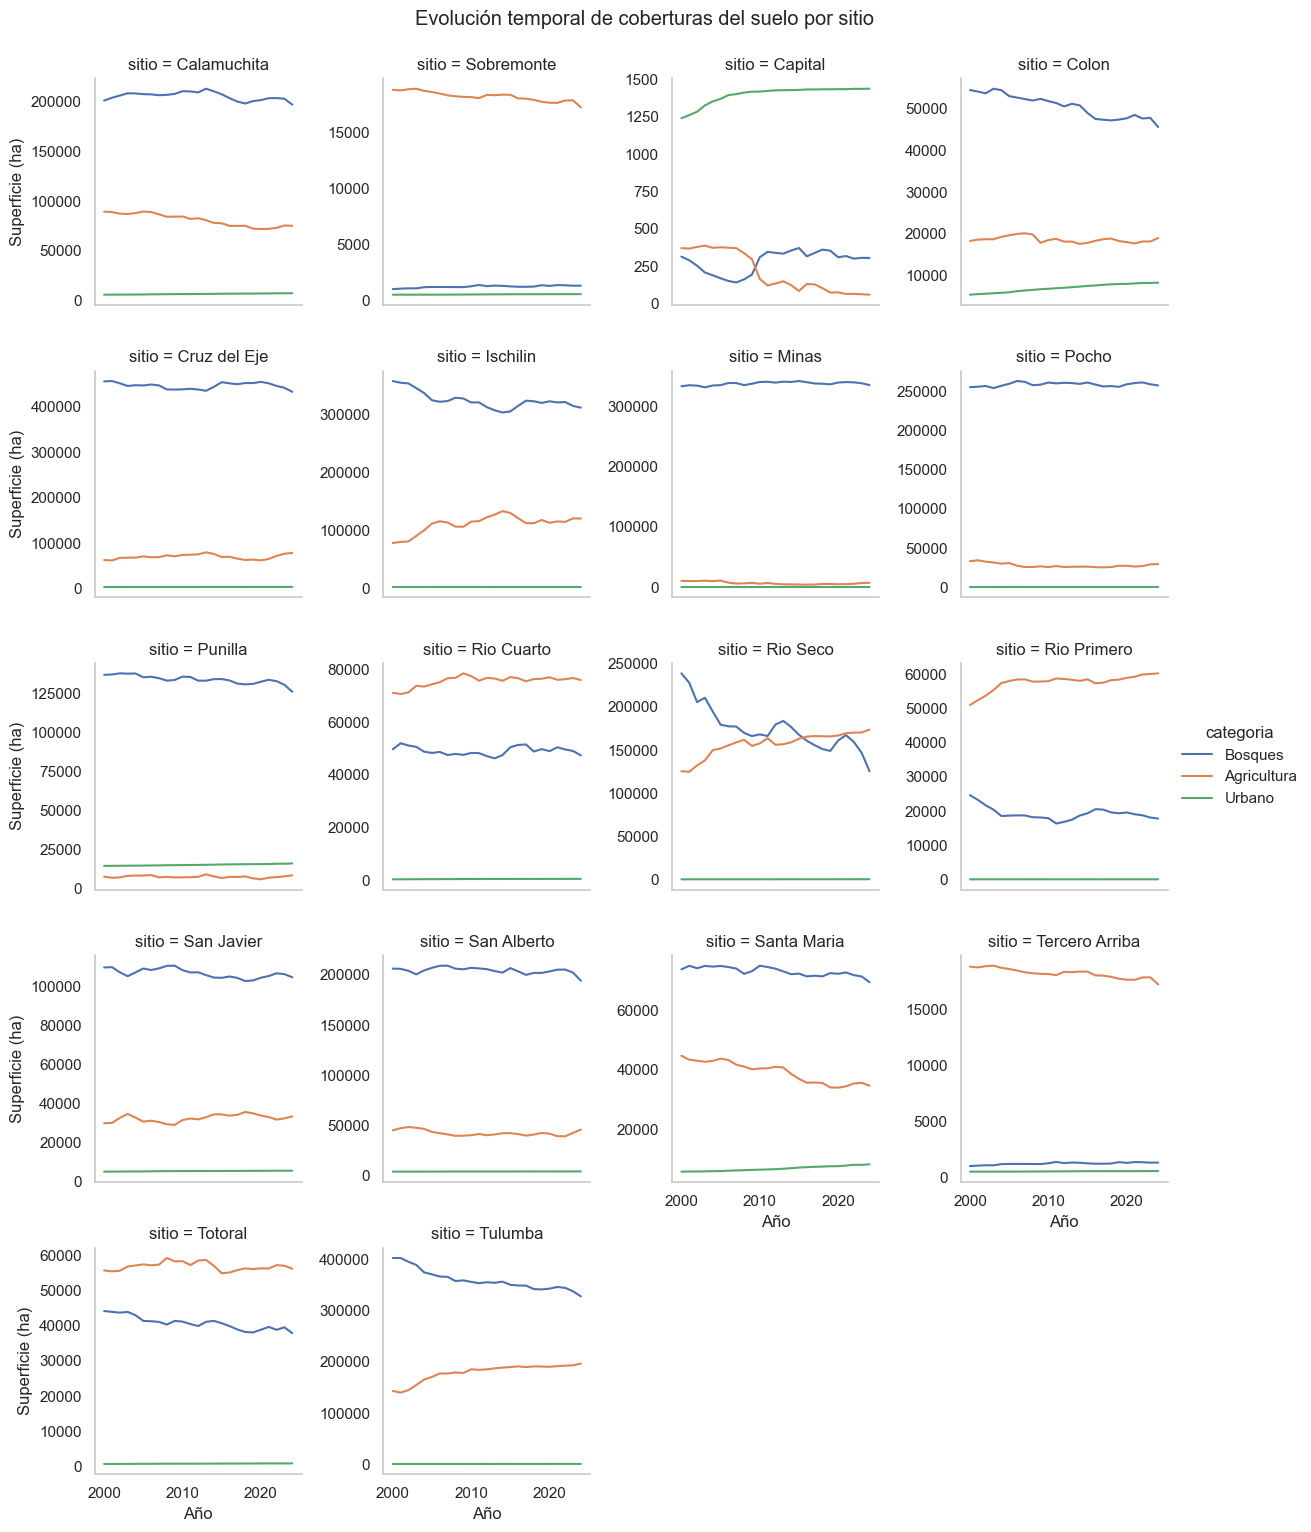

In [24]:
# 4. EVOLUCIÓN DE COBERTURAS DEL SUELO

df_cob = pd.read_csv(
    "D:/Josefina/Proyectos/Bosques/data/cobertura.csv",
    encoding="latin1"
)

df_cob = df_cob[df_cob["year"] >= 2000]

# Transformación a formato largo
df_long = df_cob.melt(
    id_vars=["sitio", "year"],
    value_vars=["Bosques", "Agricultura", "Urbano"],
    var_name="categoria",
    value_name="superficie_ha"
)

g = sns.FacetGrid(df_long, col="sitio", col_wrap=4, sharey=False, height=3, hue="categoria")

g.map_dataframe(sns.lineplot, x="year", y="superficie_ha")
g.add_legend()
# Quitar grid en todos los subplots
for ax in g.axes.flatten():
    ax.grid(False)
g.set_axis_labels("Año", "Superficie (ha)")
g.fig.suptitle("Evolución temporal de coberturas del suelo por sitio", y=1.02)

plt.show()



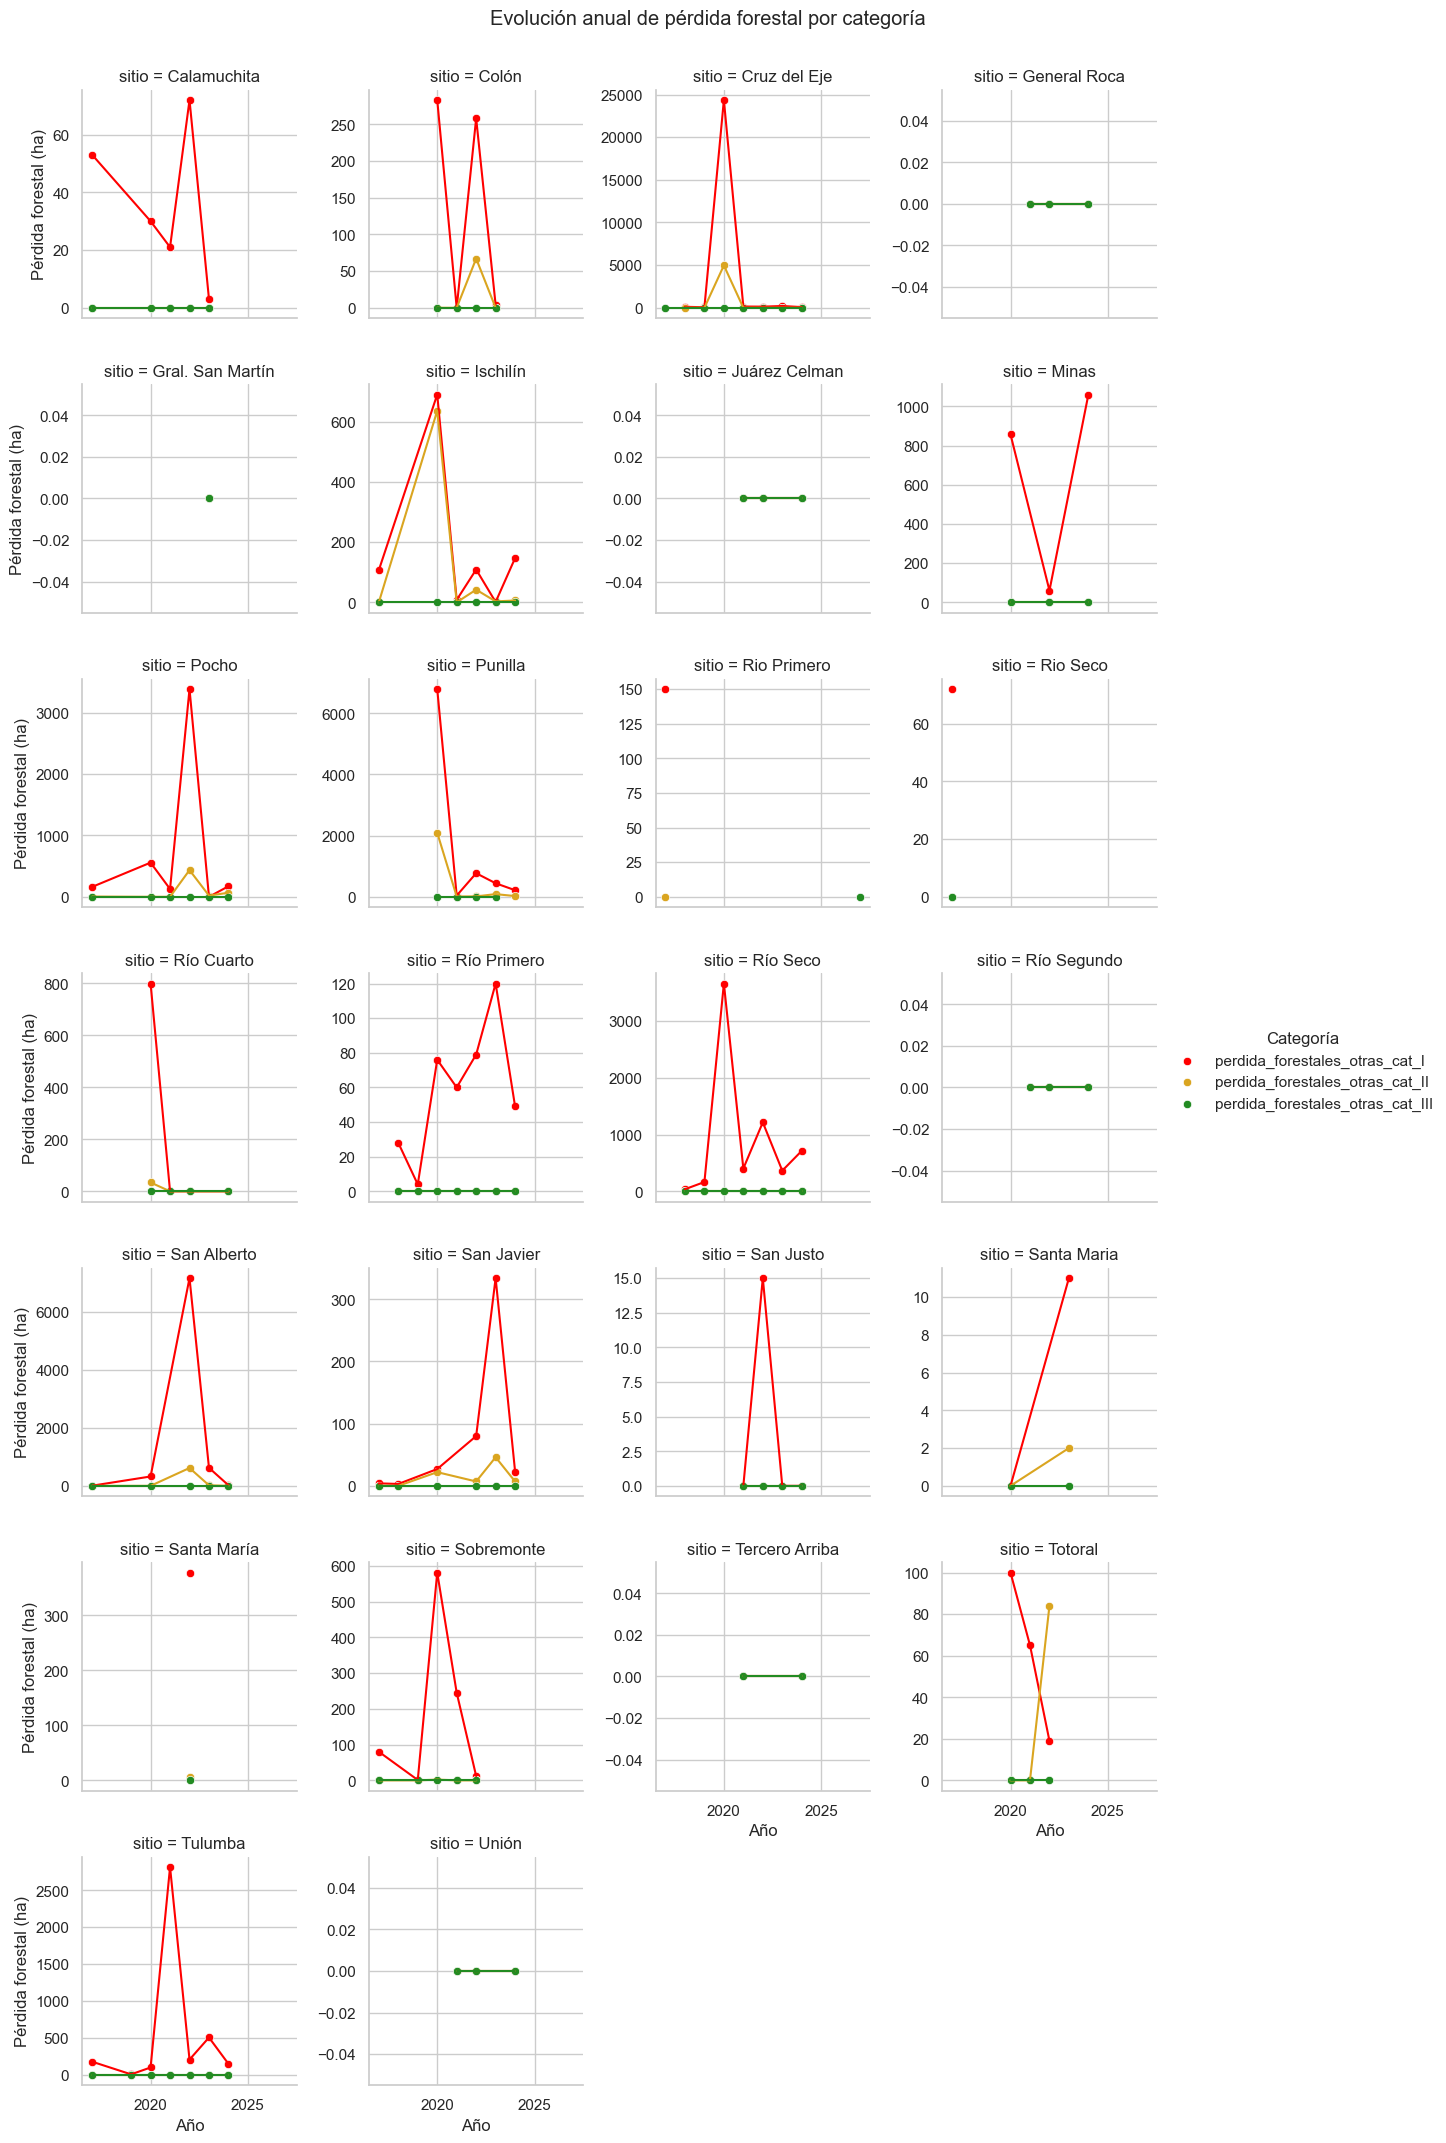

In [23]:

# 5. PÉRDIDA FORESTAL POR CATEGORÍA (I, II, III)


df_forestal = df[
    (df["resolucion_espacial"] == "dpto") &
    (df["tipo"].isin([
        "perdida_forestales_otras_cat_I ",
        "perdida_forestales_otras_cat_II ",
        "perdida_forestales_otras_cat_III"
    ]))
]

df_sum = (
    df_forestal.groupby(["sitio", "year_2", "tipo"])
    .agg(perdida_ha=("valor", "sum"))
    .reset_index()
)

palette = {
    "perdida_forestales_otras_cat_I ": "red",
    "perdida_forestales_otras_cat_II ": "goldenrod",
    "perdida_forestales_otras_cat_III": "forestgreen"
}

g = sns.FacetGrid(df_sum, col="sitio", col_wrap=4, sharey=False, height=3, hue="tipo", palette=palette)

g.map_dataframe(sns.lineplot, x="year_2", y="perdida_ha")
g.map_dataframe(sns.scatterplot, x="year_2", y="perdida_ha")

g.add_legend(title="Categoría")
g.set_axis_labels("Año", "Pérdida forestal (ha)")
g.fig.suptitle("Evolución anual de pérdida forestal por categoría", y=1.02)

plt.show()